In [1]:
import numpy as np
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# max row and columns to display
pd.set_option("display.max_rows", 500)
pd.set_option("display.max_columns", 500)

# width of DataFrame
pd.set_option("display.width", 1000)

# Float number formatting
pd.options.display.float_format = "{:,.2f}".format

# p-value decimal formatting
np.set_printoptions(suppress=True)

## Read Data from CSV

In [3]:
file_path = "C:\\Users\\User\\Downloads\\archive\\fighter_details.csv"

In [5]:
path = "C:\\Users\\User\\Downloads\\archive\\"
file_name = "fighter_details.csv"
fighter_df = pd.read_csv(path+file_name)

In [7]:
fighter_df.head()

,id,name,nick_name,wins,losses,draws,height,weight,reach,stance,dob,splm,str_acc,sapm,str_def,td_avg,td_avg_acc,td_def,sub_avg
0,8f382b3baa954d2a,Jessica Aguilar,Jag,20,8,0,160.02,52.16,160.02,Orthodox,"May 08, 1982",4.93,50,7.19,53,0.94,25,50,0.20
1,483a953b18d73bb3,Deron Winn,NaN,7,3,0,167.64,83.91,177.80,Orthodox,"Jun 13, 1989",4.55,44,6.21,46,4.28,52,40,0.00
2,232c582f29f8f65e,Gegard Mousasi,NaN,42,6,2,187.96,83.91,193.04,Orthodox,"Aug 01, 1985",3.75,50,1.21,68,1.59,60,59,1.10
3,236a37d96d476164,Mike Pierce,NaN,17,7,0,172.72,77.11,180.34,Orthodox,"Sep 01, 1980",2.62,42,2.36,62,3.08,42,71,0.20
4,203c957eac95dd87,Hyun Gyu Lim,The Ace,13,7,1,190.50,77.11,195.58,Orthodox,"Jan 16, 1985",4.45,41,5.07,51,0.23,100,73,0.20


In [8]:
fighter_df.shape

(2611, 19)

In [9]:
fighter_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2611 entries, 0 to 2610
Data columns (total 19 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          2611 non-null   object 
 1   name        2611 non-null   object 
 2   nick_name   1692 non-null   object 
 3   wins        2611 non-null   int64  
 4   losses      2611 non-null   int64  
 5   draws       2611 non-null   int64  
 6   height      2590 non-null   float64
 7   weight      2593 non-null   float64
 8   reach       1956 non-null   float64
 9   stance      2534 non-null   object 
 10  dob         2455 non-null   object 
 11  splm        2611 non-null   float64
 12  str_acc     2611 non-null   int64  
 13  sapm        2611 non-null   float64
 14  str_def     2611 non-null   int64  
 15  td_avg      2611 non-null   float64
 16  td_avg_acc  2611 non-null   int64  
 17  td_def      2611 non-null   int64  
 18  sub_avg     2611 non-null   float64
dtypes: float64(7), int64(7), ob

In [10]:
fighter_df.describe()

,wins,losses,draws,height,weight,reach,splm,str_acc,sapm,str_def,td_avg,td_avg_acc,td_def,sub_avg
count,"2,611.00","2,611.00","2,611.00","2,590.00","2,593.00","1,956.00","2,611.00","2,611.00","2,611.00","2,611.00","2,611.00","2,611.00","2,611.00","2,611.00"
mean,14.52,6.17,0.25,178.30,76.60,182.03,2.97,40.91,3.41,48.95,1.39,32.09,50.42,0.58
std,9.73,4.53,0.79,8.96,17.93,10.76,1.71,14.80,1.86,15.80,1.48,25.26,29.38,1.06
min,0.00,0.00,0.00,152.40,52.16,147.32,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,9.00,3.00,0.00,172.72,65.77,175.26,1.86,36.00,2.38,45.00,0.19,10.00,33.00,0.00
50%,13.00,5.00,0.00,177.80,70.31,182.88,2.93,43.00,3.26,52.00,1.00,33.00,56.00,0.30
75%,18.00,8.00,0.00,185.42,83.91,190.50,3.96,50.00,4.31,58.00,2.07,47.00,71.50,0.80
max,253.00,53.00,11.00,210.82,349.27,213.36,13.53,100.00,22.50,100.00,13.95,100.00,100.00,21.90


## Take the Data to analyze

### Take column

In [12]:
# create a variable as a Data Series for 'str_acc'
strike_acc = fighter_df["str_acc"]

<Axes: >

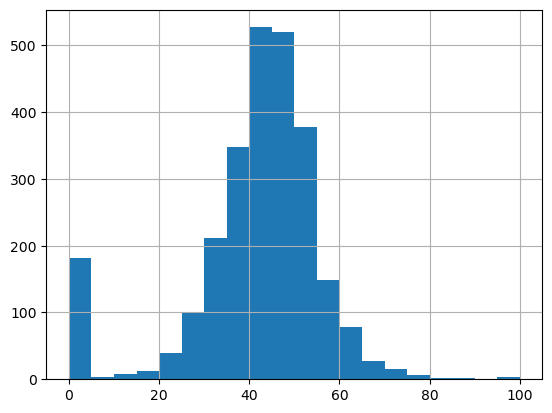

In [13]:
# see the distribution of this variable with Histogram
strike_acc.hist(bins=20)

In [8]:
# see the description (statistics)
strike_acc.describe()

count   2,611.00
mean       40.91
std        14.80
min         0.00
25%        36.00
50%        43.00
75%        50.00
max       100.00
Name: str_acc, dtype: float64

In [15]:
# check if there are null values
strike_acc.isna().sum()

np.int64(0)

<Axes: >

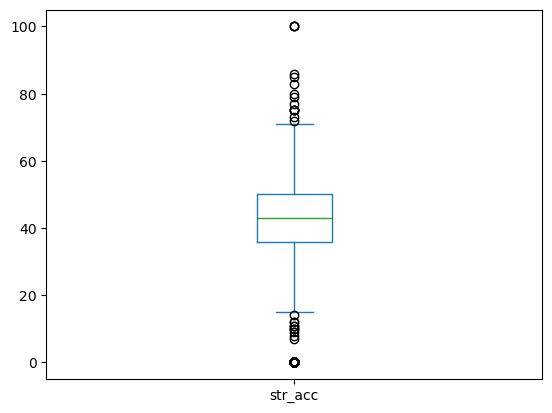

In [10]:
# see the distribution with Box plot
strike_acc.plot(kind="box")

In [18]:
strike_acc.quantile([0.25, 0.5, 0.75])

0.25   36.00
0.50   43.00
0.75   50.00
Name: str_acc, dtype: float64

In [19]:
# interqauntile range
int_quant_range = strike_acc.quantile(0.75) - strike_acc.quantile(0.25)
print(int_quant_range)

14.0


In [21]:
lower_bound = strike_acc.quantile(0.25) - 1.5 * int_quant_range
upper_bound = strike_acc.quantile(0.75) + 1.5 * int_quant_range

## Central Limit Theorem

In [22]:
# take 2600 data points as population to divide into equal samples
strike_acc_2600 = strike_acc[:2600]
print(strike_acc_2600.mean())

40.885384615384616


In [23]:
# divide into samples
sample_means = []
for i in range(0, 2600, 50):
    _mean = strike_acc_2600[i:i+50].mean()
    sample_means.append(_mean)
print(sample_means[:10])
print(np.mean(sample_means))

[np.float64(37.9), np.float64(39.38), np.float64(39.36), np.float64(40.2), np.float64(38.34), np.float64(40.44), np.float64(39.5), np.float64(43.44), np.float64(40.26), np.float64(41.2)]
40.88538461538461


In [25]:
print("population mean:", strike_acc_2600.mean())
print("sampling mean:", np.mean(sample_means))

print(strike_acc_2600.mean() == np.mean(sample_means))

print(round(strike_acc_2600.mean(), 6) == round(np.mean(sample_means), 6))

population mean: 40.885384615384616
sampling mean: 40.88538461538461
False
True


<Axes: >

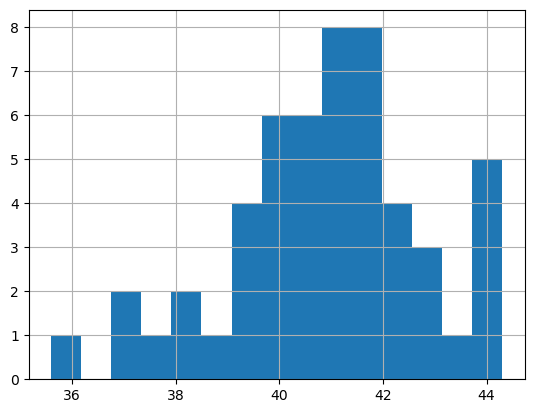

In [28]:
pd.Series(sample_means).hist(bins=15)

### Take random Data Points

In [31]:
# create a sample of 500 data points (randomly chosen)
strike_acc_sample = strike_acc.sample(n=500, random_state = 42)

In [32]:
# see the description (statistics)
strike_acc_sample.describe()

count   500.00
mean     40.60
std      15.28
min       0.00
25%      36.00
50%      44.00
75%      50.00
max      85.00
Name: str_acc, dtype: float64

<Axes: >

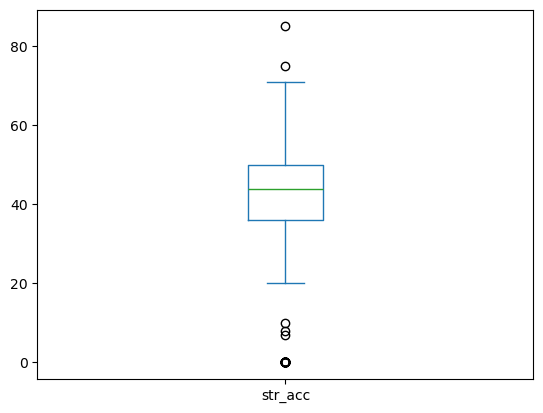

In [33]:
# see the distribution with Box plot
strike_acc_sample.plot(kind='box')

<Axes: >

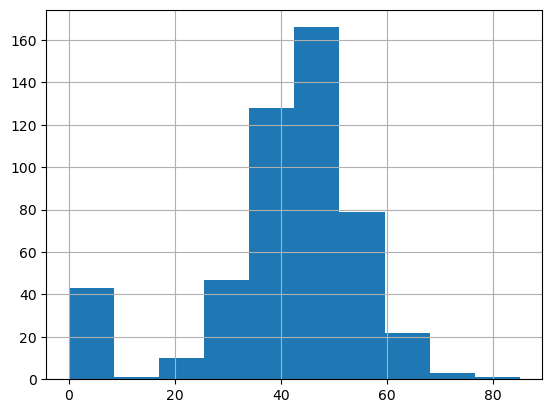

In [34]:
# see the distribution with Histogram
strike_acc_sample.hist()

## Hypothesis Testing

### Two-tailed z-test

#### **Set question and confidence level**
- H0 ---> sample mean = hypothetical population mean.
- H1 ---> sample mean <> hypothetical population mean.

In [35]:
# set the confidence level
conf_level = 0.95
# set the alpha
alpha = round(1 - conf_level,2)
print(alpha)

0.05


In [62]:
# set the hypothetical population mean and population std
population_mean = 42
population_std = 14.8

#### **Take the values to calculate z-score**

In [63]:
# take population std, sample mean and sample size and assign them to variables
sample_mean = float(strike_acc_sample.mean())
sample_size = strike_acc_sample.shape[0]
print(sample_mean)

40.602


#### **Calculate z-score**

In [64]:
z_score = (sample_mean - population_mean) / (population_std / np.sqrt(sample_size))
z_score

np.float64(-2.1121777246923736)

#### **Calculate the p-value**

In [65]:
# Calculate the p-value
p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))
print(p_value)

0.03467120836526605


#### **Final Decision**

In [67]:
# Final Decision
print(f"Sample Mean: {sample_mean:.2f}")
print(f"Z-score: {z_score:.2f}")
print(f"P-value: {p_value:.5f}")

if p_value < alpha:
    print("Reject H0 → Statistically significant difference.")
else:
    print("Fail to reject H0 → No statistically significant difference.")

Sample Mean: 40.60
Z-score: -2.11
P-value: 0.03467
Reject H0 → Statistically significant difference.


### Right-tailed z-test

#### **Set question and confidence level**
- H0 ---> sample mean <= hypothetical population mean.
- H1 ---> sample mean > hypothetical population mean.

In [68]:
# set the confidence level
conf_level = 0.95
# set the alpha
alpha = round(1 - conf_level,2)
print(alpha)

0.05


In [92]:
# set the hypothetical population mean and population std
population_mean = 39
population_std = 14.8

#### **Take the values to calculate z-score**

In [93]:
# take population std, sample mean and sample size and assign them to variables
sample_mean = float(strike_acc_sample.mean())
sample_size = strike_acc_sample.shape[0]
print(sample_mean)

40.602


#### **Calculate Z-score**

In [94]:
z_score = (sample_mean - population_mean) / (population_std / np.sqrt(sample_size))
z_score

np.float64(2.420392499969362)

#### **Calculate p-value**

In [95]:
p_value = 1 - stats.norm.cdf(z_score)
print(p_value)

0.007751881297645591


#### **Final Decision**

In [96]:
print(f"Sample Mean: {sample_mean:.2f}")
print(f"Z-score: {z_score:.2f}")
print(f"P-value: {p_value:.5f}")

if p_value < alpha:
    print("Reject H0 → The sample mean is statistically significantly higher than the population mean.")
else:
    print("Fail to reject H0 → The sample mean is not statistically significantly higher than the population mean.")

Sample Mean: 40.60
Z-score: 2.42
P-value: 0.00775
Reject H0 → The sample mean is statistically significantly higher than the population mean.


### Left-tailed z-test

#### **Set question and confidence level**
- H0 ---> sample mean >= hypothetical population mean.
- H1 ---> sample mean < hypothetical population mean.

In [97]:
# set the confidence level
conf_level = 0.95
# set the alpha
alpha = round(1 - conf_level,2)
print(alpha)

0.05


In [104]:
# set the hypothetical population mean and population std
population_mean = 45
population_std = 14.8

In [105]:
# take population std, sample mean and sample size and assign them to variables
sample_mean = float(strike_acc_sample.mean())
sample_size = strike_acc_sample.shape[0]
print(sample_mean)

40.602


#### **Calculate Z-score**

In [106]:
z_score = (sample_mean - population_mean) / (population_std / np.sqrt(sample_size))
z_score

np.float64(-6.64474794935411)

#### **Calculate p-value**

In [107]:
p_value = stats.norm.cdf(z_score)
print(p_value)

1.51868196213e-11


#### **Final Decision**

In [108]:
print(f"Sample Mean: {sample_mean:.2f}")
print(f"Z-score: {z_score:.2f}")
print(f"P-value: {p_value:.5f}")

if p_value < alpha:
    print("Reject H0 → The sample mean is statistically significantly lower than the population mean.")
else:
    print("Fail to reject H0 → The sample mean is not statistically significantly lower than the population mean.")

Sample Mean: 40.60
Z-score: -6.64
P-value: 0.00000
Reject H0 → The sample mean is statistically significantly lower than the population mean.
